# Urban Mobility and Economic Performance in Latin America

## Introducción

El objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. Para ello se trabajo con datos reales de TomTom Traffic Index y OECD Cities, para identificar en qué ciudades conviene invertir en infraestructura de transporte.

---

## 🧩 Paso 1: Cargar y explorar

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


---

## 🧩 Paso 2: Explorar, limpiar y preparar los datos

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, y anotar las columnas que requieren conversión.

In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### 2.2 Renombrar columnas

Se estandarizan los nombres de las columnas al formato `snake_case` para evitar errores y facilitar la unión de los datasets (por ejemplo, `Country` → `country`, `UpdateTimeUTC` → `update_time_utc`).

In [ ]:
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_in_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_per_10kms_mins',
    'MinsDelay': 'mins_delay'
})

traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25',
    'Population (M)': 'population_m'
})

eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

In [ ]:
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors="coerce", utc=True)

traffic.info()

In [ ]:
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)
eco['pm25'] = eco['pm25'].astype(str).str.replace(',', '.').astype(float)
eco['population'] = eco['population_m'] * 1000000

eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0


---

## 🧩 Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo:**
Identificar el año de cada registro y mantener solo los registros del 2024.

In [ ]:
traffic['year'] = traffic["update_time_utc"].dt.year

traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
traffic_2024 = traffic[traffic['year'] == 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

display(traffic_2024.head())
display(eco_2024.head())

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0


---

## 🧩 Paso 4: Analizar y resumir datos de movilidad

Dado que el dataset de tráfico contiene **múltiples registros por ciudad**, en esta sección se calculan los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

In [ ]:
traffic_city_year_2024 = traffic_2024.groupby(["city", "country", "year"])[["jams_delay", "traffic_index_live", "jams_length_in_kms", "jams_count", "mins_delay", "travel_time_live_per_10kms_mins", "travel_time_historic_per_10kms_mins"]].mean().reset_index()

traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


---

## 🧩 Paso 5: Unir movilidad y economía

Combinar datasets para analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

In [ ]:
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

merged = pd.merge(traffic_2024_small, eco_2024_small, on=['city', 'year'], how='inner')

merged.info()
merged.describe()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 15 non-null     object 
 1   country                              15 non-null     object 
 2   year                                 15 non-null     int64  
 3   jams_delay                           15 non-null     float64
 4   traffic_index_live                   15 non-null     float64
 5   jams_length_in_kms                   15 non-null     float64
 6   jams_count                           15 non-null     float64
 7   mins_delay                           15 non-null     float64
 8   travel_time_live_per_10kms_mins      15 non-null     float64
 9   travel_time_historic_per_10kms_mins  15 non-null     float64
 10  city_gdp_capita                      15 non-null     float64
 11  unemployment_pct                  

,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
count,15.0,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,1.500000e+01
mean,2024.0,629.517204,22.102749,87.858914,144.324391,0.618270,19.034347,18.416077,13253.600000,8.693333,17.060000,9.086667e+06
std,0.0,783.063726,7.480396,105.159497,168.162789,0.618267,3.270021,2.806720,5686.213802,2.259414,4.352635,6.731468e+06
min,2024.0,50.201092,11.258220,6.369201,14.160332,0.072539,13.338658,13.145216,2277.000000,3.200000,11.200000,1.800000e+06
25%,2024.0,107.165938,17.351054,17.611311,30.250647,0.166703,17.084315,16.745914,10156.500000,7.800000,14.350000,4.150000e+06
50%,2024.0,263.047879,20.155352,44.038129,68.805422,0.393442,18.304538,17.817311,12381.000000,8.500000,15.800000,6.100000e+06
75%,2024.0,841.079053,26.020448,105.301307,183.274409,0.878235,20.451702,19.813180,15477.000000,9.750000,19.050000,1.250000e+07
max,2024.0,2833.057892,37.614273,389.239265,594.969392,1.855542,25.674261,24.167956,26176.000000,12.400000,28.000000,2.260000e+07


---

## 🧩 Paso 6: Visualización y análisis de relaciones

Los gráficos ayudan a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

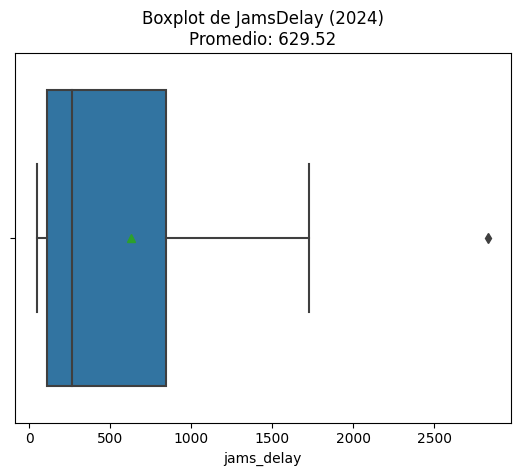

In [ ]:
sns.boxplot(data=merged, x='jams_delay', showmeans=True)

mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()

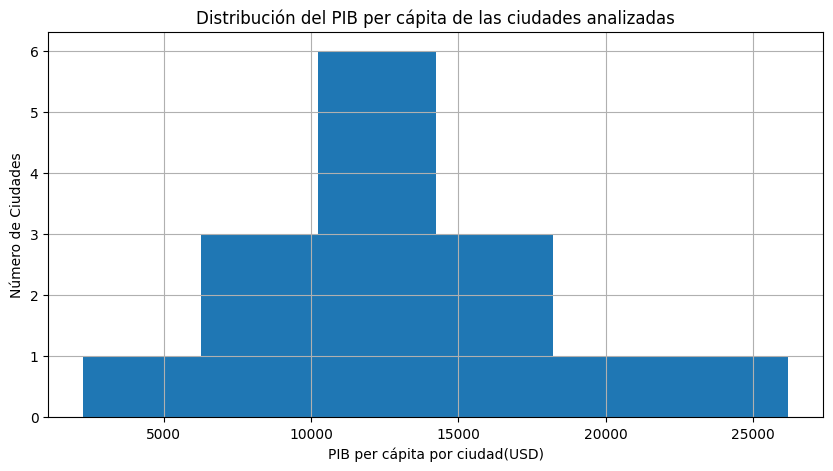

In [ ]:
merged['city_gdp_capita'].hist(bins='auto', figsize=(10, 5))
plt.title('Distribución del PIB per cápita de las ciudades analizadas')
plt.xlabel('PIB per cápita por ciudad(USD)')
plt.ylabel('Número de Ciudades')
plt.show()

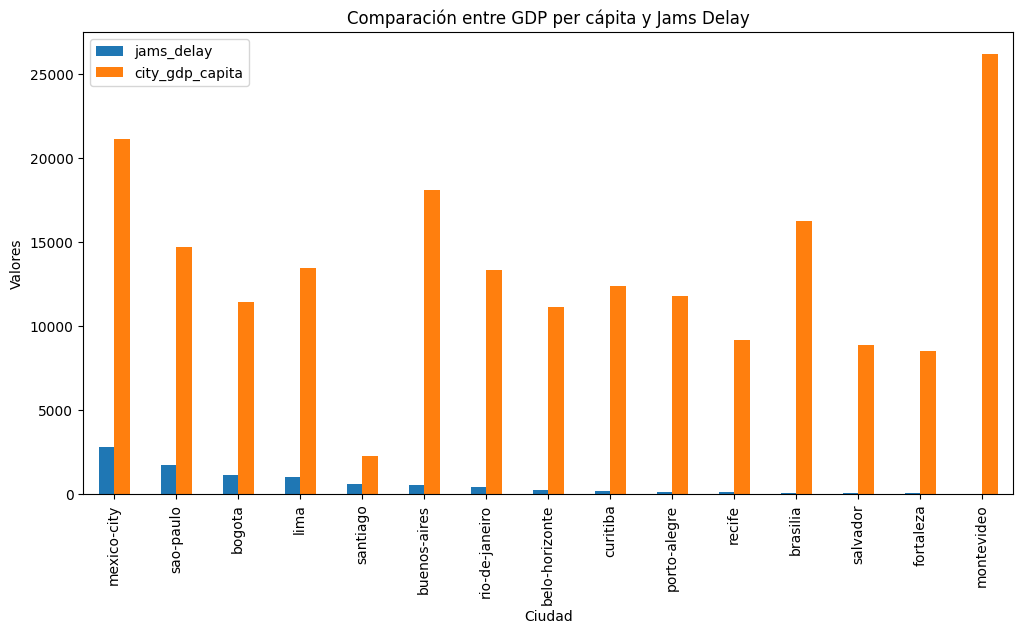

In [ ]:
merged_sorted = merged.sort_values(by='jams_delay', ascending=False)

merged_sorted.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar',
    figsize=(12,6)
)

plt.xticks(rotation=90)
plt.title('Comparación entre GDP per cápita y Jams Delay')
plt.xlabel('Ciudad')
plt.ylabel('Valores')
plt.show()

---

## 🧩 Paso 7: Exportar y documentar resultados

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

In [ ]:
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

# 🧾 Resumen Ejecutivo

## Contexto y objetivo

El presente análisis evaluó la relación entre indicadores de movilidad urbana y productividad económica en 15 ciudades principales de Latinoamérica durante 2024. Para ello se integraron variables de congestión vehicular provenientes de TomTom Traffic Index con indicadores económicos y demográficos obtenidos de OECD Cities.

El objetivo fue identificar si mayores niveles de desarrollo económico se asocian con una movilidad urbana más eficiente y detectar ciudades donde la congestión podría estar afectando la productividad, la competitividad y la calidad de vida.

## Cobertura de datos

La muestra incluyó ciudades de Argentina, Brasil, Chile, Colombia, México, Perú y Uruguay durante 2024.

Entre las ciudades analizadas se encuentran Bogotá, Lima, Ciudad de México, Santiago, São Paulo, Montevideo, Buenos Aires y Brasilia, entre otras.

Los indicadores considerados fueron:

* Índice de congestión vehicular (*traffic_index*).
* Retraso acumulado por congestión (*jams_delay*).
* Número de eventos de congestión (*jams_count*).
* Longitud de congestión (*jams_length*).
* PIB per cápita.
* Tasa de desempleo.
* Población.
* Material particulado PM2.5.

## Metodología

Se realizó un proceso de limpieza y estandarización de datos, incluyendo normalización de nombres de columnas, conversión de variables numéricas y validación de registros.

Posteriormente, los datasets de movilidad y economía fueron integrados mediante una unión (*INNER JOIN*) utilizando las variables **city** y **year** como claves principales.

Finalmente, se desarrolló un análisis exploratorio mediante histogramas, comparaciones entre ciudades y evaluación de indicadores económicos y de movilidad para identificar tendencias y posibles relaciones entre ambas dimensiones.

## Hallazgos principales

Los resultados no muestran una relación lineal evidente entre un mayor PIB per cápita y menores niveles de congestión vehicular.

Por ejemplo, **Montevideo** registra el PIB per cápita más alto de la muestra (USD 26.176) y uno de los menores niveles de congestión, con apenas **50 horas de retraso acumulado** y **14 eventos de congestión** durante el periodo analizado.

Sin embargo, **Santiago** presenta el segundo PIB per cápita más alto (USD 22.770) y registra **629 horas de retraso acumulado**, **153 eventos de congestión** y un índice de tráfico de **20,16**, evidenciando que un mayor nivel económico no garantiza una movilidad eficiente.

Los casos más críticos corresponden a:

* **Ciudad de México**, con el mayor nivel de congestión de toda la muestra:

  * 2.833 horas de retraso acumulado.
  * 595 eventos de congestión.
  * 389 km de longitud acumulada de congestión.
  * Población de 22,1 millones de habitantes.

* **São Paulo**, con:

  * 1.729 horas de retraso acumulado.
  * 431 eventos de congestión.
  * 238 km de congestión acumulada.
  * Población de 22,6 millones de habitantes.

* **Bogotá**, con:

  * Índice de tráfico de 37,6 (el más alto de la muestra).
  * 1.142 horas de retraso acumulado.
  * 231 eventos de congestión.
  * Población de 11,3 millones de habitantes.

Por otro lado, ciudades como **Brasilia** y **Montevideo** muestran mejores resultados relativos de movilidad. Brasilia presenta un PIB per cápita de USD 16.251 acompañado de solo 102 horas de retraso acumulado y 27 eventos de congestión, mientras que Montevideo combina el mayor PIB per cápita con los niveles de congestión más bajos del conjunto analizado.

## Recomendaciones

Los resultados sugieren priorizar inversiones en infraestructura de transporte y movilidad sostenible en aquellas ciudades donde coinciden elevados niveles de congestión y alta concentración de actividad económica.

En particular:

* **Ciudad de México** representa el caso más crítico debido a que concentra simultáneamente la mayor población, el mayor retraso acumulado y la mayor longitud de congestión.
* **São Paulo** presenta una situación similar, reflejando fuertes presiones sobre la infraestructura urbana derivadas de su tamaño poblacional.
* **Bogotá** registra el índice de tráfico más elevado de toda la muestra, lo que sugiere oportunidades importantes de mejora en movilidad urbana y transporte público.

Para futuras investigaciones se recomienda incorporar variables adicionales como:

* Densidad poblacional.
* Cobertura de transporte público.
* Inversión histórica en infraestructura vial.
* Crecimiento urbano.
* Indicadores de sostenibilidad ambiental.
* Calidad del aire y emisiones asociadas al tráfico.

La inclusión de estas variables permitiría construir modelos explicativos más robustos y comprender mejor los factores que determinan la movilidad urbana en las ciudades latinoamericanas.
